# Advanced 3D Box Detection: Robust Estimators
**Computer Vision Project | Winter 2026 | FAU University**

## Overview
This implementation provides a robust pipeline for estimating 3D box dimensions from ToF (Time-of-Flight) sensor data. The project explores the performance of three geometric estimators:
1. **Standard RANSAC:** Baseline for plane fitting (Floor and Box-top).
2. **MLESAC (Maximum Likelihood Estimation SAC):** A robust estimator minimizing the likelihood cost function.
3. **Preemptive RANSAC:** A real-time strategy utilizing hypothesis preemption for computational efficiency.

---
### Mathematical Background
The MLESAC cost function implemented here is defined as:
$$C = \sum_{i=1}^{N} \rho(d(s_i)), \quad \rho(d) = \begin{cases} d(s_i) & \text{if } d(s_i) < \epsilon \\ \gamma & \text{otherwise} \end{cases}$$

The Preemption function $f(i)$ follows Nister's strategy to maintain a time budget $M$:
$$f(i) = \lfloor M 2^{-\lfloor \frac{i}{B} \rfloor} \rfloor$$

In [1193]:
# import libraries and initial setup

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.image as mpimg
import numpy as np
import scipy.io
from scipy import ndimage
import os
import re
import time

%matplotlib inline

np.random.seed(42)

## First Part: Implementing MLESAC and Preemptive RANSAC Algorithm:
In order to develop this method, first we need to define some functions to:

- Plot 2D images and 3D point clouds
- Subsample data from the point cloud
- Estimate the plane equation
- Implementation of MLESAC algorithm
- Implementation of Preemptive RANSAC algorithm
- Filter using morphological operations
- Detect box corners and calculating box size


Note: The number of hypothesis is considered to be one for MLESAC Algorithm. But as we also need these functions for implementing Preemptive RANSAC so we also defined this parameter.


In [2]:
def plot_data(data, title, cmap=None):
    """
    Plot the matrix data using imshow library

    Args:
    data: the matrix we want to plot, it can be Amplitude or Distance Matrix
    title: the title of the plot
    cmap: the colormap we want to use
    """

    plt.figure(figsize=(6, 4))
    plt.imshow(data, cmap=cmap)
    plt.colorbar()
    plt.title(title)

In [3]:
def plot_cloud(points):
    """
    Plot the 3D Cloud point matrix data using matplotlib's scatter3D.

    Args:
    points: the 3D matrix we want to plot
    """
    points = points.reshape((-1, 3))

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(projection='3d')

    # Subsample the cloud points for clearer visualization of points.
    # As the number of points are too high, we visualize them by subsampling points to get a better visualization.
    n = min(10000, points.shape[0])
    idx = np.random.randint(0, points.shape[0], size=n)
    sample = points[idx]

    ax.scatter(sample[:, 0], sample[:, 1], -sample[:, 2], s=1)
    ax.set_title("3D Cloud Points")
    plt.show()

In [4]:
def check_collinearity(points):
    """This Function check the collinearity of points

    Args:
        points: a list of all the points that we want to check the collinearity

    Returns:
        is_collinear: an array of boolean values that determine the collinearity
    """
    vectors_1 = points[:, 0, :] - points[:, 1, :] # Extract the first vector(s) using first and second points of each hypothesis
    vectors_2 = points[:, 2, :] - points[:, 1, :] # Extract the second vector(s) using third and first points of each hypothesis


    # Calculate the coefficients of plane's equation using the cross product of vectors
    models = np.cross(vectors_1, vectors_2, axis=1)

    # check if there is any collinear
    eps = 1e-6
    norms = np.linalg.norm(models, axis=1)
    is_collinear = norms < eps

    return is_collinear

In [5]:
def minimal_sample(point_cloud, n_hyp=1, n_samples=3):
    """
    Randomly select a subset of points from points cloud

    Args:
        point_cloud: a list of all the points in the cloud matrix that we want to sample from it
        n_samples: number of points we want to select for each hypothesis from the cloud to define a plane using them
        n_hyp: number of hypothesis (models) - for implementing RANSAC and MLESAC algorithm the number of hypothesis is 1, but this parameter is useful for Preemptive RANSAC

    Returns:
        samples: np array of all selected points
    """

    # Randomly select a number of indicis and get the subset of points using them
    samples_idx = np.random.randint(0, point_cloud.shape[0], (n_hyp, n_samples))
    samples = point_cloud[samples_idx]
    samples = np.array(samples)

    while True:
        is_collinears = check_collinearity(samples)
        n_collinears = np.sum(is_collinears)

        if n_collinears > 0:
            samples_idx = np.random.randint(0, point_cloud.shape[0], (n_collinears, n_samples))
            samples[is_collinears] = point_cloud[samples_idx]
        else:
            break

    return samples

In [6]:
def estimate_model(points):
    """
    Calculate the equation of the plane(s) using three sample points for each hypothesis

    Args:
        points: list of the hypothesis that each includes three points, we want to estimate the plane(s) from them

    Returns:
        model: an array that includes the plane's equation for each hypothesis, which a list containing the coefficients of the equations
        d: the bias of the estimated model(s)
    """

    # Make sure that points array contains exactly 3 sample points
    assert(points.shape[1] == 3)

    # Calculate two vectors that can be used for the model equation
    vectors_1 = points[:, 0, :] - points[:, 1, :] # Extract the first vector(s) using first and second points of each hypothesis
    vectors_2 = points[:, 2, :] - points[:, 1, :] # Extract the second vector(s) using third and first points of each hypothesis

    # Calculate the coefficients of plane's equation using the cross product of vectors
    models = np.cross(vectors_1, vectors_2, axis=1)

    # Normalize the model's coefficients
    norms = np.linalg.norm(models, axis=1, keepdims=True)
    norms[norms == 0] = 1  # To avoid dividing by zero
    models = models / norms

    # Using one point to calculate the model's bias for each hypothesis
    sample_point = points[:, 0, :]
    d = np.sum(models * sample_point, axis=1)

    return models, d

In [7]:
def compute_inliers(all_points, model, d, thresh):
    """
    Compute the number of points from the whole cloud points, that are in the given plane(s) considering a threshold.

    Args:
        all_points: all the points in the cloud points
        model: a list of coefficients that define the plane's equation for each hypothesis
        d: the bias of the plane's model(s)
        thresh: a threshold for calculating the inlier points

    Returns:
        mask: a binary mask the separate the plane inlier points and the outlier points
        n_inliers: number of inlier points for each hypothesis
    """

    # Calculate the distance of all points from the plane(s)
    distances = np.abs(np.dot(all_points, model.T) - d)
    # Mask all the inliers (the points that their distance from the plane are below threshold)
    mask = distances < thresh
    # Count the number of inliers
    n_inliers = np.sum(mask, axis=0)

    return mask, n_inliers

## RANSAC Algorithm

The RANSAC implementation here fits a plane model to a 3D point cloud by iteratively sampling 3 random points, estimating a plane, and counting inliers
within a distance threshold ε. Invalid points (z=0) are automatically excluded. The function takes three parameters: the point cloud, a distance threshold,
and the maximum number of iterations.

In [190]:
def ransac(all_points, max_iteration=100, n_samples=3, thresh=0.1):
    """
    The RANSAC algorithm which trys to estimate the best model by finding the inlier points.

    Args:
        all_points: all the points in the cloud points
        max_iteration: the maximum number of iterations to run the ransac algorithm
        n_samples: the number of samples we want to select from the cloud to estimate the plane
        thresh: a threshold for calculating the inlier points

    Returns:
        best_model: the best model that can separate the two planes in our image
        best_d: the best bias for the model
    """

    best_model = None
    best_d = None
    max_inliers = -1

    # Define a mask to filter out all the invalid points (points with z = 0)
    valid_mask = all_points[:, 2] != 0
    valid_points = all_points[valid_mask]

    for _ in range(max_iteration):
        # Sample 3 random points from the point cloud
        samples = minimal_sample(valid_points, 1, n_samples)

        # Estimate a plane using the random points
        model, d = estimate_model(samples)

        # Calculate the number of inliner points for the estimated plane
        _, n_inliers = compute_inliers(valid_points, model, d, thresh)

        # Save the best model
        if n_inliers > max_inliers:
            best_model = model
            best_d = d
            max_inliers = n_inliers

    # While we considered n_hyp parameter in estimating planes and we set this parameter to 1 for RANSAC algorithm, our model and bias have additional dimension now that we can remove it.
    best_model = np.squeeze(best_model)
    best_d = np.squeeze(best_d)

    return best_model, best_d


## MLESAC Algorithm:

MLESAC extends RANSAC by replacing the binary inlier/outlier scoring with a likelihood-based cost function. Instead of simply counting inliers, inlier points
contribute their actual distance error to the cost, while outliers contribute a fixed penalty γ. This makes the algorithm less sensitive to the choice of threshold ε,
as the cost function distinguishes between "close inliers" and "far inliers" rather than treating all inliers equally.

In [191]:
def compute_cost_mlesac(all_points, model, d, thresh, y):
    """
    Compute the cost of each model on the whole cloud points

    Args:
        all_points: all the points in the cloud points
        model: a list of coefficients that define the plane's equation
        d: the bias of the plane's model
        thresh: the threshold error
        y: constant error using when the error is larger than error threshold

    Returns:
        mask: a binary mask the separate the plane inlier points and the outlier points
        cost: the calculated cost
    """

    # Calculate the distance of all points from the given plane
    error = np.abs(np.dot(all_points, model.T) - d)
    mask = error < thresh
    error[error >= thresh] = y
    cost = np.sum(error, axis=0)

    return mask, cost

In [192]:
def mlesac(all_points, max_iteration, thresh, y, n_samples=3):
    """
    The MLESAC algorithm which trys to estimate the best model by using Maximum Likelihood Estimation

    Args:
        all_points: all the points in the cloud points
        max_iteration: the maximum number of iterations to run the ransac algorithm
        n_samples: the number of samples we want to select from the cloud to estimate the plane
        thresh: a threshold for calculating the inlier points
        y: constant error using when the error is larger than error threshold

    Returns:
        best_model: the best model that can separate the two planes in our image
        best_d: the best bias for the model
    """

    best_model = None
    best_d = None
    min_cost = float('inf')

    # Define a mask to filter out all the invalid points (points with z = 0)
    valid_mask = all_points[:, 2] != 0
    valid_points = all_points[valid_mask]

    for _ in range(max_iteration):
        # Sample 3 random points from the point cloud
        samples = minimal_sample(valid_points, 1, n_samples)

        # Estimate a plane using the random points
        model, d = estimate_model(samples)

        _, cost = compute_cost_mlesac(valid_points, model, d, thresh, y)

        # save the best model
        if cost < min_cost:
            best_model = model
            best_d = d
            min_cost = cost

    best_model = np.squeeze(best_model)
    best_d = np.squeeze(best_d)

    return best_model, best_d


## Preemptive RANSAC Algorithm

Preemptive RANSAC addresses the computational cost of standard RANSAC by generating all M hypotheses upfront and evaluating them in parallel on small batches of data.
After each batch, hypotheses are ranked and the worst-performing ones are eliminated using Nister's preemption function f(i) = floor(M · 2^(-floor(i/B))), where B is
the batch size. This continues until a single hypothesis remains, making it significantly faster and well-suited for real-time applications. This implementation
also supports MLESAC scoring as an optional mode via the `use_mlesac` parameter.

In [547]:
def preemptive_ransac(all_points, n_hyp=100, n_samples=3, thresh=0.1, batch_size=100, use_mlesac=False, y=1):
    """
    The preemptive ransac algorithm which trys to estimate the best model with using different hypothesis

    Args:
        all_points: all the points in the cloud points
        n_hyp: the number of hypotheses to select
        n_samples: the number of samples we want to select from the cloud to estimate the plane
        thresh: a threshold for calculating the inlier points
        use_mlesac: a boolean parameter for the use of mlesac cost or not

    Returns:
        best_model: the best model that can separate the two planes in our image
        best_d: the best bias for the model
    """

    best_model = None
    best_d = None
    max_inliers = -1

    # Define a mask to filter out all the invalid points (points with z = 0)
    valid_mask = all_points[:, 2] != 0
    valid_points = all_points[valid_mask]

    # shuffle points
    valid_points = valid_points.copy()
    np.random.shuffle(valid_points)

    batches = np.array_split(valid_points, int(np.ceil(len(valid_points) / batch_size)))
    costs = np.zeros(n_hyp)

    i = 0
    # Sample 3 random points from the point cloud
    samples = minimal_sample(valid_points, n_hyp, n_samples)

    # Estimate a plane using the random points
    models, ds = estimate_model(samples)

    for i in range(len(batches)):

        if use_mlesac:
            # Calculate the cost using mlesac for the estimated plane
            _, cost = compute_cost_mlesac(batches[i], models, ds, thresh, y)
            costs += cost
            idx_sorted = np.argsort(costs)
        else:
            # Calculate the number of inliner points for the estimated plane
            _, n_inliers = compute_inliers(batches[i], models, ds, thresh)
            costs += n_inliers
            idx_sorted = np.argsort(costs)[::-1]


        # Select top models
        n_points = (i + 1) * batch_size
        f = int(np.floor(n_hyp * (2 ** (-(n_points // batch_size)))))
        if f > len(models):
            f = len(models)

        if f < 1:
            f = 1
        models = models[idx_sorted][:f]
        ds = ds[idx_sorted][:f]

        costs = costs[idx_sorted][:f]

        if f == 1:
            best_d = ds[0]
            best_model = models[0]
            break

    if len(models) > 1:
        best_model = models[0]
        best_d = ds[0]

    return best_model, best_d


In [548]:
def filter_mask(mask, structure=None):
    """
    Filter the mask using some morphological operations.

    Args:
        mask: the mask we want to do the morphological operations on

    Returns:
        mask_filtered: the filtered mask
        mask_filtered_flat: the flattened filtered mask
    """
    if structure is None:
        structure = np.ones((5, 5))

    # Remove noise by opening
    mask_opened = ndimage.binary_opening(mask, structure=structure)

    # Remove small holes of the image
    mask_closed = ndimage.binary_closing(mask_opened, structure=structure)

    mask_filtered = mask_closed
    mask_filtered_flat = mask_filtered.flatten()

    return mask_filtered, mask_filtered_flat


In [549]:
def get_largest_component(mask):
    """
    Find the largest connected component in the image using label command

    Args:
        mask: the binary mask that we want to pick the largest connected component from it

    Returns:
        largest_component_mask: the binary mask that shows the largest connected component
    """

    # Label all connected parts in the mask
    labels, n_components = ndimage.label(mask)

    # Calculate the size of each label
    labels_list = range(n_components + 1)
    components_size = ndimage.sum(mask, labels, labels_list)

    # Pick the largest connected component
    largest_component_label = components_size.argmax()
    largest_component_mask = labels == largest_component_label

    return largest_component_mask


In [550]:
def select_corners(mask):
    """
    Another implementation of selecting corners to find the four corners of the box image

    Args:
        mask: a mask which has the value of 1 for box top

    Returns:
        corners: a dictionary of all four corners of the box image
    """

    corners = dict([])

    # Store the x and y coordinates of top of the box
    xs, ys = np.where(mask == 1)


    # get the index of each corner in the matrix
    c1_idx = np.argmin(xs)
    c2_idx = np.argmax(ys)
    c3_idx = np.argmax(xs)
    c4_idx = np.argmin(ys)

    # save the x and y coordinates of each corner into 'corners' dictionary
    corners['corner_1'] = (ys[c1_idx], xs[c1_idx]) # Min x coordinate is the first corner
    corners['corner_2'] = (ys[c2_idx], xs[c2_idx]) # Max y coordinate is the second corner
    corners['corner_3'] = (ys[c3_idx], xs[c3_idx]) # Max x coordinate is the third corner
    corners['corner_4'] = (ys[c4_idx], xs[c4_idx]) # Min y coordinate is the fourth corner

    return corners


In [551]:
def calculate_box_size(cloud, corners, mask, model, d):
    """
    Calculate the size of the box with its length and width

    Args:
        cloud: the cloud points
        corners: a dictionary including all four corners with their coordinates
        mask: a mask of the top of the box
        model: model of the box plane
        d: the bias for the model of the box plane

    Returns:
        box_length: length of the box top
        box_width: width of the box top
        box_height: height of the box
        box_size: size of the box

    """
    # Get the list of all keys in the corners dictionary
    keys = list(corners.keys())  # [corner_1, corner_2, corner_3, corner_4]

    box_length = np.linalg.norm(cloud[int(corners[keys[1]][1]), int(corners[keys[1]][0])] - cloud[int(corners[keys[2]][1]), int(corners[keys[2]][0])])
    box_width = np.linalg.norm(cloud[int(corners[keys[2]][1]), int(corners[keys[2]][0])] - cloud[int(corners[keys[3]][1]), int(corners[keys[3]][0])])

    # Calculating the height of th box
    xs, ys = np.where(mask == 1)

    x_center = xs.mean()
    y_center = ys.mean()

    box_top_center = cloud[int(x_center), int(y_center)]
    box_height = np.abs(np.dot(box_top_center, model) - d)

    # Calculating size of the box
    box_size = box_width * box_height * box_length

    return box_length, box_width, box_height, box_size

In [552]:
def plot_corners(mask, corners):
    """
    Visualize the clean top mask with indicating its corners

    Args:
        mask: the mask we want to plot its corners
        corners: a dictionary including all four corners with their coordinates
    """

    plt.figure(figsize=(6, 4))
    plt.imshow(mask, cmap=mcolors.ListedColormap(['blue', 'red']))

    for corner in corners:
        x, y = corners[corner]
        plt.scatter(x, y, c="lime", s=25)
        plt.text(x + 5, y - 5, corner, color="lime", fontsize=10)

    plt.title('box top with corner annotations')
    plt.show()

# Load Data
Our dataset includes four samples. Each of them includes:

- `amplitudes`: amplitude image
- `distances`: distance image
- `cloud`: 3D point cloud


In [1730]:
# Defining the data path and all the sample examples available for the project

data_path = "./data/"
files = []
for file in os.listdir(data_path):
        files.append(file)
files = sorted(files)
print("Our examples are:", files)

Our examples are: ['example1kinect.mat', 'example2kinect.mat', 'example3kinect.mat', 'example4kinect.mat']


# Testing our three different Algorithms

In this section, we apply all three algorithms: RANSAC, MLESAC, and Preemptive RANSAC, to the same ToF sensor data and compare their results. The algorithm can be switched using the `algorithm` parameter in the configuration cell below.

In [1749]:
# Pre-define some parameters
cmap = mcolors.ListedColormap(['red', 'blue'])

# Define parameters for ransac algorithm
max_iteration = 100
n_samples = 3

thresh = 0.05 # I tried these values: 0.01, 0.05, 0.10, 0.12  -note that this threshold is used for detecting the floor plane.
thresh_2 = 0.005  # this threshold is used for detecting the top box plane.
y_mle = thresh * 2


n_hyp = 10 # should be one for RANSAC and MLESAC algorithm   # For Preeptive: tried 5, 10, 100, 500
batch_size = 100  # Tried: 1, 10, 100, 500
use_mlesac = True

algorithm = "PREE_RANSAC"  # it can be "RANSAC", "MLESAC" or "PREE_RANSAC"


In [1750]:
# Check all the files we have for each example and print them out for example i

exampleNumber = 1

ex_path = os.path.join(data_path, files[exampleNumber - 1])
matfiles = scipy.io.loadmat(ex_path)

print("All the files we have for sample example",  exampleNumber, ":")
for i in matfiles.keys():
    print(i)

print("=" * 100)
print("All the matrix we have for sample example",  exampleNumber, "and their shape:")
for i in matfiles.keys():
    if not i.startswith('__'):
        print(i, "shape:", matfiles[i].shape)

All the files we have for sample example 1 :
__header__
__version__
__globals__
amplitudes1
distances1
cloud1
All the matrix we have for sample example 1 and their shape:
amplitudes1 shape: (424, 512)
distances1 shape: (424, 512)
cloud1 shape: (424, 512, 3)


In [1751]:
# Store the matrices of the example

Amplitude = matfiles['amplitudes' + str(exampleNumber)]
Distance = matfiles['distances' + str(exampleNumber)]
Cloud_points = matfiles['cloud' + str(exampleNumber)]

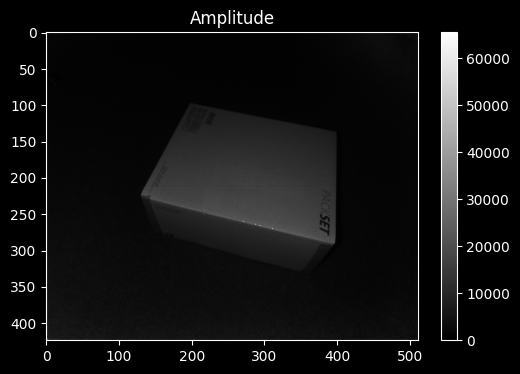

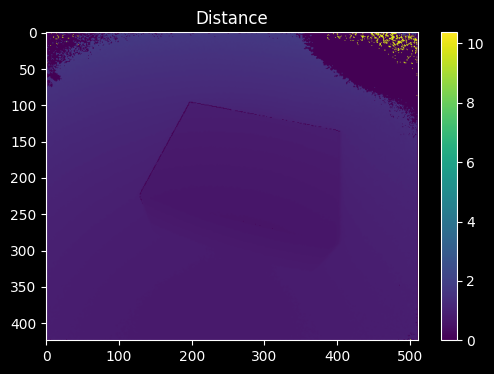

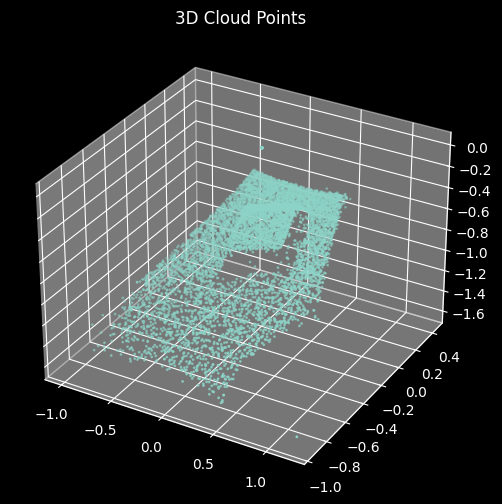

In [1752]:
# Plot all the 3 matrices that are available for each example

plot_data(Amplitude, "Amplitude", "gray")
plot_data(Distance, "Distance", None)

plot_cloud(Cloud_points)


## Floor Plane
For finding the floor plane, we will use RANSAC to estimate its plane.


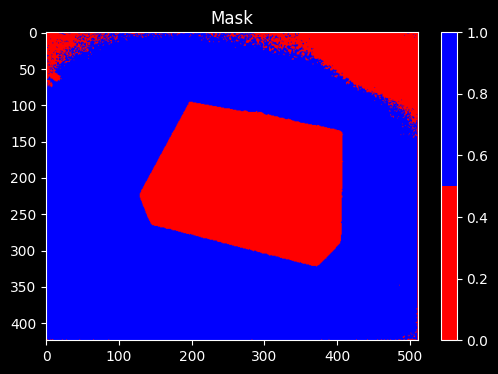

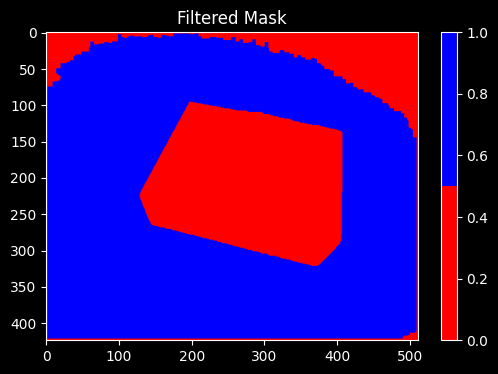

In [1753]:
# Reshape the point cloud to a numpy array only containing points
cloud_reshaped = Cloud_points.reshape(-1, 3)

# Estimate a model for the floor based on the chosen algorithm

floor_model, floor_d = None, None

if algorithm == "RANSAC":
    floor_model, floor_d = ransac(cloud_reshaped, max_iteration, n_samples, thresh)
    floor_mask_flat, _ = compute_inliers(cloud_reshaped, floor_model, floor_d, thresh)
elif algorithm == "MLESAC":
    floor_model, floor_d = mlesac(cloud_reshaped, max_iteration, thresh, y_mle, n_samples)
    floor_mask_flat, _ = compute_cost_mlesac(cloud_reshaped, floor_model, floor_d, thresh, y_mle)
elif algorithm == "PREE_RANSAC":
    time_0 = time.time()
    floor_model, floor_d = preemptive_ransac(cloud_reshaped, n_hyp, n_samples, thresh, batch_size, use_mlesac, y_mle)
    time_1 = time.time()
    pree_time = time_1 - time_0
    if use_mlesac:
        floor_mask_flat, _ = compute_cost_mlesac(cloud_reshaped, floor_model, floor_d, thresh, y_mle)
    else:
        floor_mask_flat, _ = compute_inliers(cloud_reshaped, floor_model, floor_d, thresh)
else:
    print("Algorithm not exist")

# Reshape the mask using the original shape of Cloud
floor_mask = floor_mask_flat.reshape(Cloud_points.shape[0], Cloud_points.shape[1])
plot_data(floor_mask, "Mask", cmap=cmap)

# Filter the mask using morphological operators
structure = np.ones((5,5))
floor_mask_filtered, floor_mask_filtered_flat = filter_mask(floor_mask, structure)

# Plotting the floor filtered mask after ransac calculation
plot_data(floor_mask_filtered, "Filtered Mask", cmap=cmap)


## Box Top Plane
After having the floor mask and finding the floor plane, now we use RANSAC again to find top plane of box.


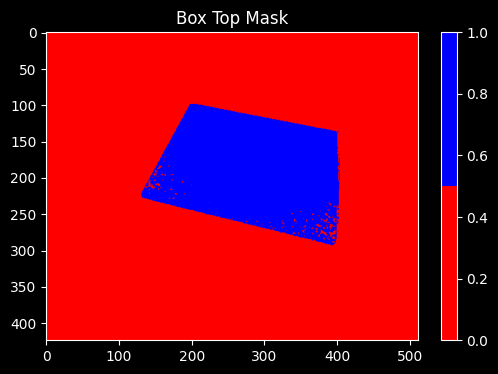

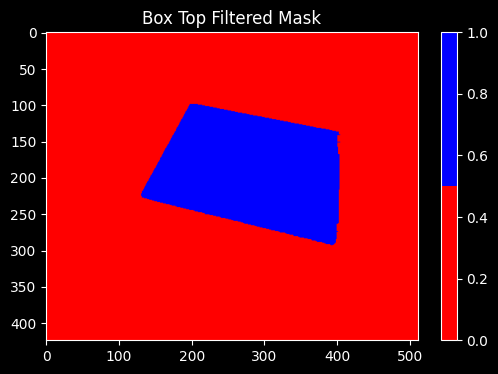

In [1754]:
# Estimate the best plane model for the box in the point cloud
non_floor_mask = ~floor_mask_filtered_flat
non_floor_points = cloud_reshaped[non_floor_mask]

## Estimate the box top based on the chosen algorithm
best_model, best_d = None, None

if algorithm == "RANSAC":
    best_model, best_d = ransac(non_floor_points, max_iteration, n_samples, thresh_2)
    top_box_mask_flat, _ = compute_inliers(cloud_reshaped, best_model, best_d, thresh_2)
elif algorithm == "MLESAC":
    best_model, best_d  = mlesac(non_floor_points, max_iteration, thresh_2, y_mle, n_samples)
    top_box_mask_flat, _ = compute_cost_mlesac(cloud_reshaped, best_model, best_d, thresh_2, y_mle)
elif algorithm == "PREE_RANSAC":
    best_model, best_d  = preemptive_ransac(non_floor_points, n_hyp, n_samples, thresh_2, batch_size, use_mlesac, y_mle)
    if use_mlesac:
        top_box_mask_flat, _ = compute_cost_mlesac(cloud_reshaped, best_model, best_d, thresh_2, y_mle)
    else:
        top_box_mask_flat, _ = compute_inliers(cloud_reshaped, best_model, best_d, thresh_2)
else:
    print("Algorithm not exist")

top_box_mask = top_box_mask_flat.reshape(Cloud_points.shape[0], Cloud_points.shape[1])
plot_data(top_box_mask, "Box Top Mask", cmap)

# Remove small holes of the image
structure = np.ones((5,5))
# top_mask_filtered = ndimage.binary_opening(top_box_mask, structure=structure)
top_mask_filtered = ndimage.binary_closing(top_box_mask, structure=structure)

top_box_mask = get_largest_component(top_mask_filtered)

plot_data(top_box_mask, "Box Top Filtered Mask", cmap)

## Find box Corners and its Size
Now we will first detect the corners of the box and use them to calculate the size of the box.

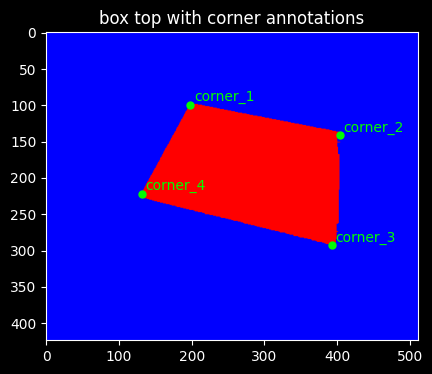

In [1755]:
# Get the corners and plot them
corners = select_corners(top_box_mask)
plot_corners(top_box_mask, corners)

In [1756]:
# Calculate the box size
box_length, box_width, box_height, box_size = calculate_box_size(Cloud_points, corners, top_box_mask, floor_model, floor_d)
print("Box Length:", box_length)
print("Box Width:", box_width)
print("Box Height:", box_height)
print("Box Size:", box_size)

Box Length: 0.3465603944172001
Box Width: 0.44215603472265563
Box Height: 0.1817283729269018
Box Size: 0.027846923660924873


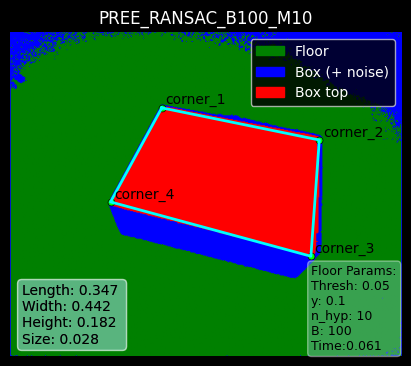

In [1757]:
# Final Visualisation of the overall result of the project

labels = np.zeros_like(floor_mask, dtype=np.uint8)

# divide the image into three labels: floor, top box, other parts
labels[floor_mask] = 0
labels[~floor_mask] = 1
labels[top_box_mask] = 2

plt.figure(figsize=(6, 4))
plt.imshow(labels, cmap=mcolors.ListedColormap(['green', 'blue', 'red']), vmin=0, vmax=3)
title = algorithm

tmp = ""
params_info = "Floor Params:" + "\n" + "Thresh: " + str(thresh)
if algorithm == "RANSAC":
    tmp = "_Thresh" + str(thresh)
elif algorithm == "MLESAC":
    tmp = "_Thresh" + str(thresh) + "_Y" + str(y_mle)
    params_info += "\n" + "y: " + str(y_mle)
elif algorithm == "PREE_RANSAC":
    tmp = "_B" + str(batch_size) + "_M" + str(n_hyp)
    if use_mlesac:
        params_info += "\n" + "y: " + str(y_mle)
    params_info += "\n" + "n_hyp: " + str(n_hyp) + "\n" + "B: " + str(batch_size)
    params_info += "\n" + "Time:" + f"{pree_time:.3f}"

title += tmp
plt.title(title)

# Plot the corners of the box top
for corner in corners:
    x, y = corners[corner]
    plt.scatter(x, y, c="lime", s=25, edgecolors='k', linewidths=0.5)
    plt.text(x + 5, y - 5, corner, color="black", fontsize=10)

# Plot the Edges of the box top
x_borders = [corners['corner_1'][0], corners['corner_2'][0], corners['corner_3'][0], corners['corner_4'][0], corners['corner_1'][0]]
y_borders = [corners['corner_1'][1], corners['corner_2'][1], corners['corner_3'][1], corners['corner_4'][1], corners['corner_1'][1]]
plt.plot(x_borders, y_borders,color='cyan', linewidth=2)

#Set labels for the plot
legend_patches = [
    mpatches.Patch(color='green', label='Floor'),
    mpatches.Patch(color='blue', label='Box (+ noise)'),
    mpatches.Patch(color='red', label='Box top'),
]
plt.legend(handles=legend_patches, loc='upper right', frameon=True)

plt.tight_layout()
plt.axis('off')

# Show size information
size_info = f"Length: {box_length:.3f} \nWidth: {box_width:.3f} \nHeight: {box_height:.3f} \nSize: {box_size:.3f}"
plt.text( 0.03, 0.03, size_info, transform=plt.gca().transAxes, ha="left", va="bottom", color="black", bbox=dict(boxstyle="round", alpha=0.4))

# Show params infor
plt.text( 0.03, 0.03, size_info, transform=plt.gca().transAxes, ha="left", va="bottom", color="black", bbox=dict(boxstyle="round", alpha=0.4))
plt.text( 0.77, 0.01, params_info, transform=plt.gca().transAxes, fontsize=9, ha="left", va="bottom", color="black", bbox=dict(boxstyle="round", alpha=0.4))

# save the final visualization image
result_folder = "results/" + algorithm
os.makedirs(result_folder, exist_ok=True)

res_file_name = result_folder + "/ex" + str(exampleNumber) + tmp + ".png"
plt.savefig(res_file_name, bbox_inches='tight', pad_inches=0)

plt.show()

# Discussion of the Results

In [1758]:
def show_all_results(path, sort_base):

    # Read all images in the path
    files = []
    for file in os.listdir(path):
        if file.lower().endswith(".png"):
            files.append(file)

    # Sort files based on their Thresh
    files = sorted(files, key=lambda file: float(re.search(sort_base, file).group(1)))

    images = []

    for file in files:
        image_path = os.path.join(path, file)
        images.append(mpimg.imread(image_path))


    # Plot all images
    fig, axes = plt.subplots(1, len(images), figsize=(20, 10))

    for ax, img in zip(axes, images):
        ax.imshow(img)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

ransac_img_path = "results/" + "RANSAC"
mlesac_img_path = "results/" + "MLESAC"
preeRan_img_path = "results/" + "PREE_RANSAC"


### First, let's take a look at the results of using **RANSAC** Algorithm all in once:

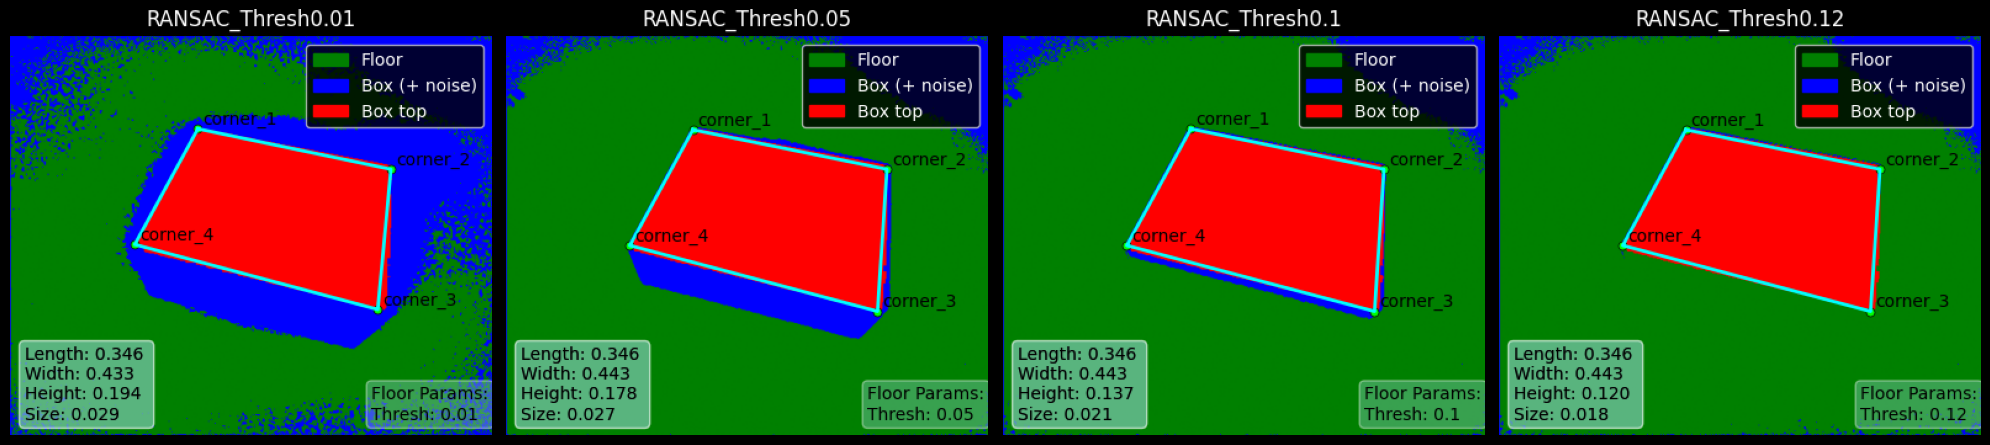

In [1693]:
# Show Ransac results
sort_base = r"Thresh([0-9]*\.?[0-9]+)"
show_all_results(ransac_img_path, sort_base)

As we can see in the results, by increasing the value of threshold, our detected floor plane became bigger and bigger. So when we have thresh = 0.01 which is the lowest experimented threshold, the model could not detect all parts of the floor, and some parts of its plane are not recognized. But with increasing the threshold, at the end when we used thresh = 0.12, even some part of th box, are detected to be a part of plane.
And here, the best value that we reached for the floor plane detection is thresh = 0.05.

### Then, let's take a look at the results of using **MLESAC** Algorithm instead:

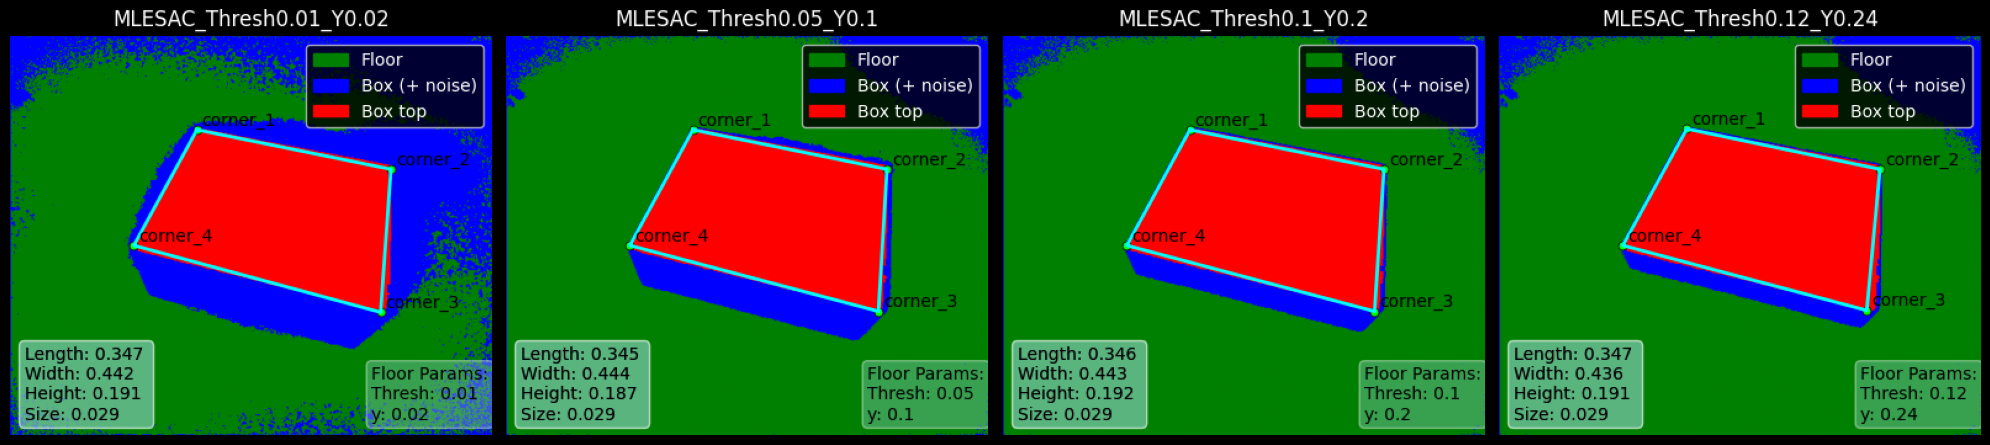

In [1604]:
# Show MLESAC results
sort_base = r"Thresh([0-9]*\.?[0-9]+)"
show_all_results(mlesac_img_path, sort_base)

By comparing the results of RANSAC and MLESAC algorithms, and by using different values for parameters, we can see that when we increased the threshold the influence of this hyperparameter is somehow less in MLESAC. For example, if we look at the third images (thresh = 0.1), Ransac floor plane is changed more than MLESAC and the most part of the box height has gone with RANSAC and has been considered as floor. Or when we used thresh = 0.12, Ransac detected all parts of box height as floor and failed, but we can see a better performance in MLESAC.

So threshold is having more effect when we used RANSAC. But why this actually happen?
In RANSAC, we treat all points the same, and we use 0 or 1 cost for all of them. If they are inliers, they are having 0 cost, and all outliers have the cost of 1. So the model just counts the inliers.
That is why when we change threshold, more impact and changes in the plane can be seen.
But in MLESAC, the model use maximum likelihood estimation instead of just counting inliers, so now the inliers are also having a cost which is their distance, and the points above the threshold will get a higher cost which is y. So MLESAC is less sensitive to threshold.

However, to get a good result in MLESAC, we need to choose the value of y properly, and it should be larger than the threshold. In this case, we are sure that the
outliers are having higher cost, so the model can distinguish them better. That's why the value of y is set to be 2 times bigger than thresh in this exercise.


So we can conclude that the advantage of using MLESAC, is that it can detect the plane with better accuracy, less noisy, and more robust to the value of threshold comparing to RANSAC.
And for the disadvantages of using this algorithm, we can refer to the fact that now we have two hyperparameters that should be tunned and also the calculation of cost is more complicated and more time consuming comparing to RANSAC.

### Finally, let's check the results of using **Preemptive RANSAC** Algorithm:

We can now see the results of using Preemptive RANSAC algorithm. We used different values for two additional hyperparameters of this method: the number of hypotheses and the batch size.
First, we can see the results of changing the number of hypotheses:

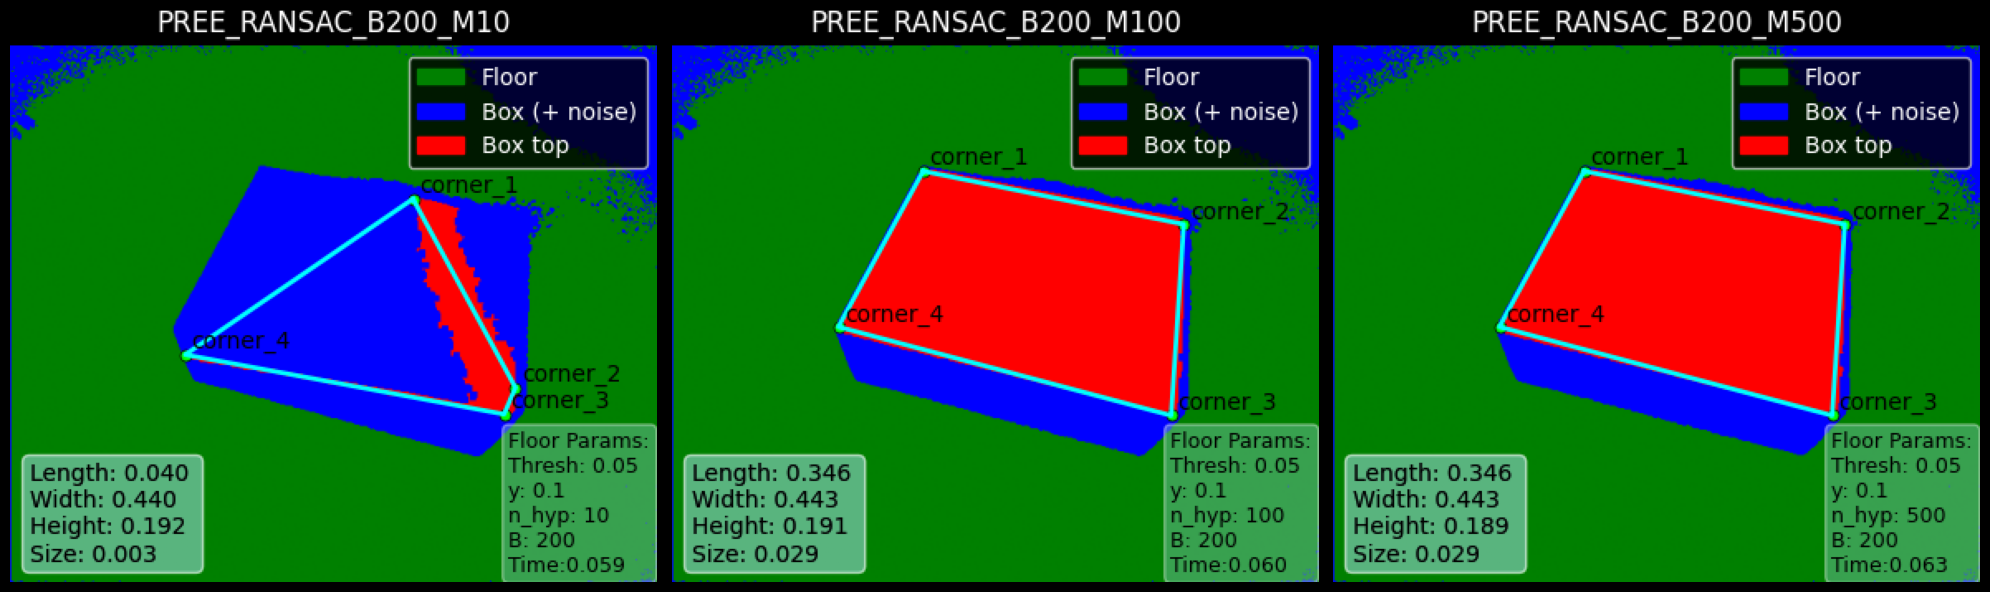

In [1605]:
# Show Preemptive RANSAC results for fixed B
preeRan_img_path_B = "results/" + "PREE_RANSAC/fixed_B"
show_all_results(preeRan_img_path_B, r"M([0-9]*)")

Here we can see the results of using Preemptive RANSAC Algorithm.
First we fixed the value of batch size to 200 and tested our data with different number of hypotheses.
As we can see in the plots, by having a low number of hypotheses, the model can not detect the planes well and it fails. This is because when we have a low number of models, the chance of having a good model between them is lower, comparing when we have more hypotheses.
So when we increased the number of hypotheses the model could detect planes very well.
Also, by increasing the number of hypotheses, we have seen that it takes more time to reach the best model. For n_hyp = 10, it took 0.059 seconds, and for n_hyp = 500, it took 0.063 second to compute.


Now, let's check the results for different batch size:

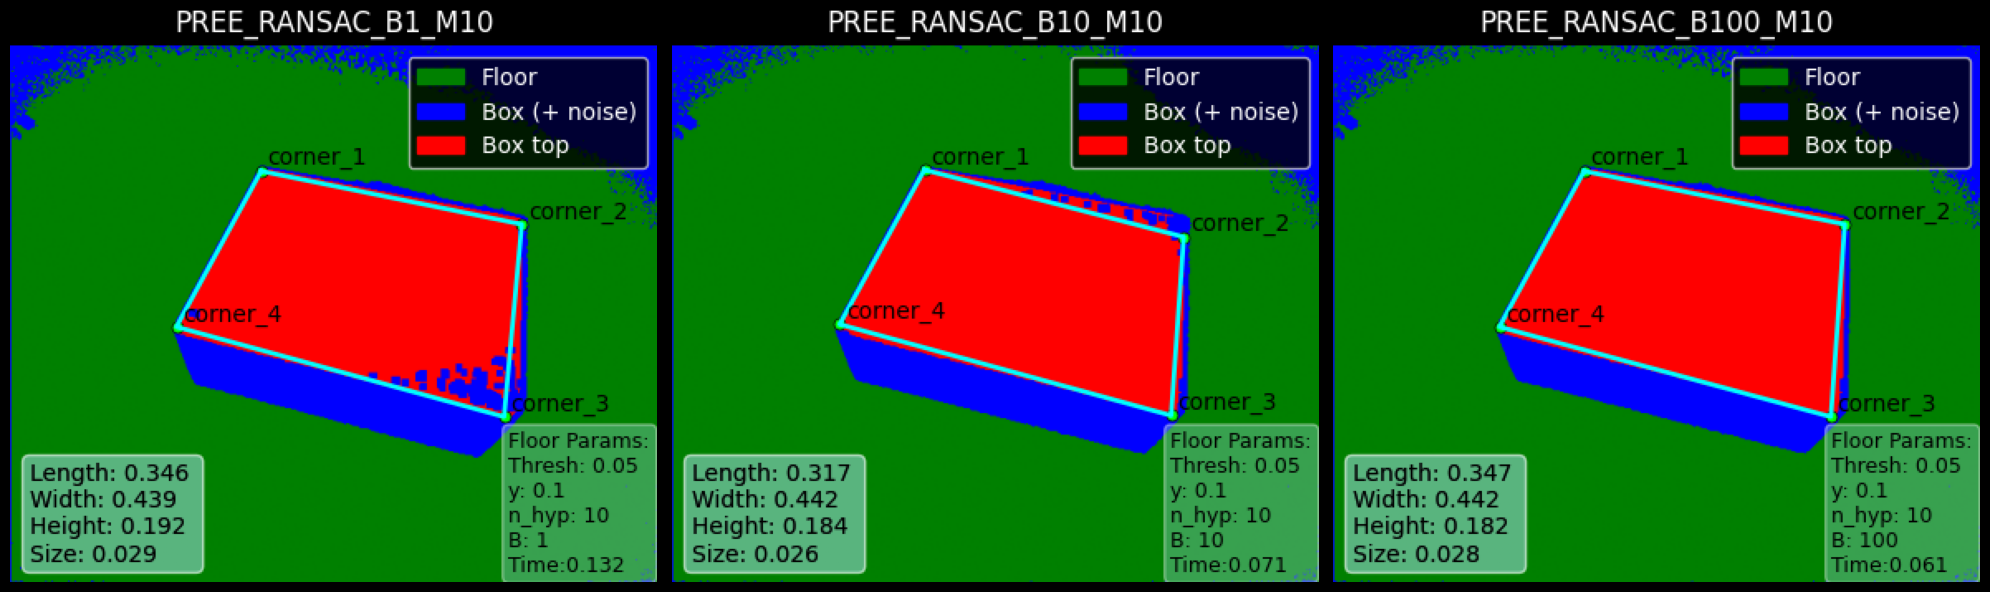

In [1759]:
# Show Preemptive RANSAC results for fixed M
preeRan_img_path_B = "results/" + "PREE_RANSAC/fixed_M"
show_all_results(preeRan_img_path_B, r"B([0-9]*)")

Then, we fixed the value of number of hypotheses, and tested our data with different batch size.
By increasing the number of batch size, we can see an improvement in the results of plane detection, so the planes are more stable when we have a larger number of points in each batch. Also when we increased the batch size, the model consumes less time to reach the best model.

Overall, by using preemptive RANSAC, we can save a lot of time, because it is less time consuming and it can remove bad hypotheses so quickly.
However, it has also some disadvantages. Because we maintain many hypotheses in memory, so it needs more memory, and also one other disadvantage of this method could be that sometimes it can ignore the best model just because it was not performing good in the first batch of data.